## Setup

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp/Project.toml`
⌃ [13f3f980] CairoMakie v0.15.11
  [074ae576] CarloAnalysis v1.0.0-DEV `../CarloAnalysis.jl`
  [a93c6f00] DataFrames v1.8.2
  [033835bb] JLD2 v0.6.4
⌅ [ee78f7c6] Makie v0.24.11
  [eff96d63] Measurements v2.14.1
⌃ [295af30f] Revise v3.14.5
  [a601b020] WignerMolecule v1.0.0-DEV `.`
  [37e2e46d] LinearAlgebra v1.12.0
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by compatibility constraints from upgrading. To see why use `status --outdated`


In [2]:
if !@isdefined Expectations
    include("Expectation.jl")
end

Main.Expectations

In [3]:
using .Expectations
using CairoMakie
using CarloAnalysis
using DataFrames
using JLD2
using LinearAlgebra
using Makie
using Measurements

In [4]:
function Measurements.measurement(e::Expectation)
    return e.val ± e.err
end

function cumulant(moms::Vector{T}, ord) where {T <: Real}
    M = Matrix{T}(undef, ord, ord)
    for I in eachindex(IndexCartesian(), M)
        i, j = Tuple(I)
        mom = i-j < 0 ? 1 : moms[i-j+1]
        M[I] = mom * binomial(i-1, max(j-2, 0))
    end
    return (-1)^(ord+1) * det(M)
end

function cumulant(As, Hs, ord)
    if ord == 1
        cumulant = As[1]
    elseif ord == 2
        cumulant = As[2] - Hs[1]*As[1]
    elseif ord == 3
        cumulant = As[3] - 2*Hs[1]*As[2] - Hs[2]*As[1] + 2*Hs[1]^2*As[1]
    elseif ord == 4
        cumulant = As[4] - 3*Hs[1]*As[3] - 3*Hs[2]As[2] - Hs[3]*As[1] +
            6*Hs[1]^2*As[2] + 6*Hs[2]*Hs[1]*As[1] - 6*Hs[1]^3*As[1]
    else
        cumulant = 0 ± 0
    end
    return cumulant
end


"""
    getexpansion(name, ord)

Read high-T expansion coefficients for energy from JLD2 file to order ord,
returns closure accepting T
"""
function getexpansion(name, ord; L::Int=8)
    all_data = load("expectations.jld2")
    energies = [measurement(all_data["$name/HH$i"]) for i in 0:ord]
    cumulants = [cumulant(energies, i) for i in 1:(ord+1)]
    return T -> getfield.(sum([(-1/T)^i / factorial(i) for i in 0:ord] .* cumulants), :val) ./ L^2
end

"""
    getexpansion(name, ord, symbol)

TBW
"""
function getexpansion(name, ord, symbol::String)
    all_data = load("expectations.jld2")
    As = [measurement(all_data["$name/$(symbol)H$i"]) for i in 0:ord]
    Hs = [measurement(all_data["$name/HH$i"]) for i in 0:ord]
    cumulants = getfield.([cumulant(As, Hs, i) for i in 1:(ord+1)], :val)
    return T -> sum([(-1/T)^i / factorial(i) for i in 0:ord] .* cumulants)
end

getexpansion

## Stripe

In [30]:
results = JobResult("../jobs", "stripe-high-t")

JobResult("../jobs", "stripe-high-t", 12×53 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     M ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  - ⋯
   2 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   4 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   5 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  - ⋯
   6 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   7 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   8 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   9 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.… 

In [31]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.08333333333333333

In [32]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["stripe/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["stripe/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["stripe/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 -0.0013 ± 0.001
  2.1513 ± 0.0022
  -0.275 ± 0.011
  0.0081 ± 0.043

4-element Vector{Measurement{Float64}}:
 0.0156185 ± 6.3e-6
 -0.001417 ± 1.9e-5
  0.033796 ± 4.2e-5
  -0.01392 ± 0.00016

4-element Vector{Measurement{Float64}}:
 0.0104167 ± 7.3e-6
 -0.000133 ± 1.5e-5
  0.022551 ± 3.6e-5
  -0.00397 ± 0.00013

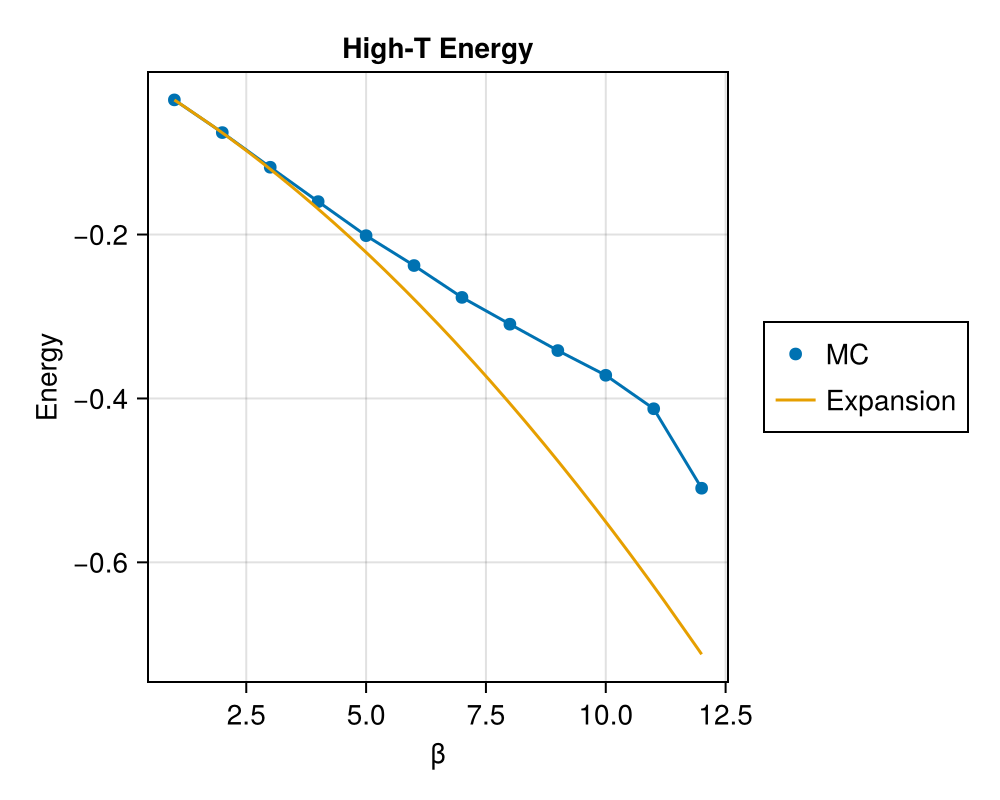

In [33]:
fig = Figure(size=(500,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="β", ylabel="Energy")
generate_plot!(ax1, :β, :Energy, results.data, label="MC")
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("stripe", 2) ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,2], ax1)
save("plots/stripe_highT_energy.png", fig)
fig

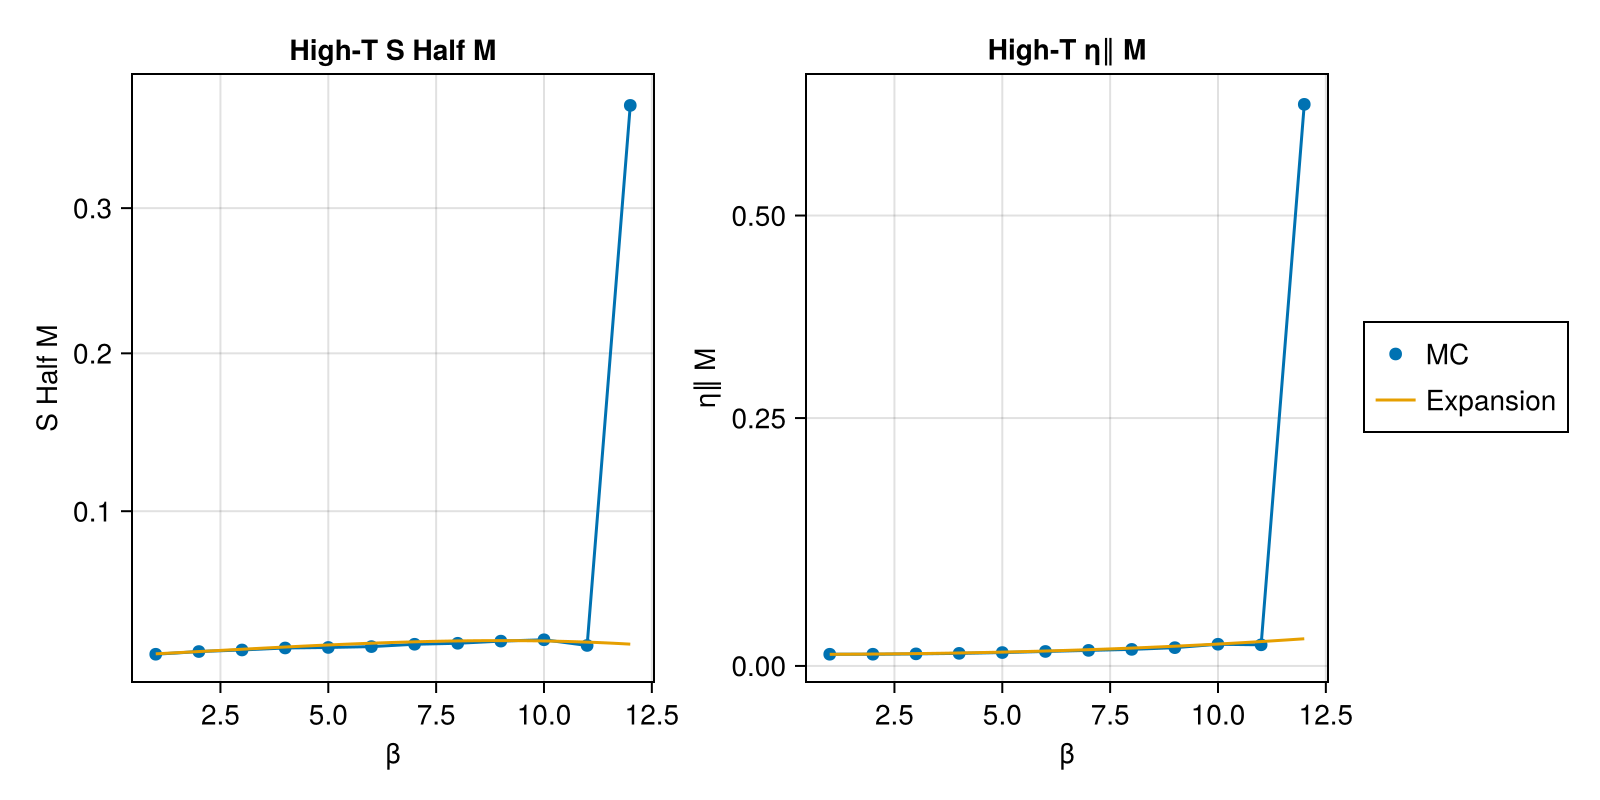

In [37]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S Half M", xlabel="β", ylabel="S Half M", yscale=Makie.pseudolog10)
generate_plot!(ax1, :β, :sk_corr_half_M, results.data)
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("stripe", 3, "s") ∘ (T -> 1/T), label="Expansion")
fig[1,2] = ax2 = Axis(fig, title="High-T η∥ M", xlabel="β", ylabel="η∥ M", yscale=Makie.pseudolog10)
generate_plot!(ax2, :β, :ηk_corr_M, results.data, label="MC") do ηk
    real(getindex(ηk, 1, 1) + getindex(ηk, 2, 2))
end
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("stripe", 3, "η") ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,3], ax2)
save("plots/stripe_highT_mag.png", fig)
fig

## FM

In [25]:
results = JobResult("../jobs", "fm-high-t")

JobResult("../jobs", "fm-high-t", 13×75 DataFrame
 Row │ χηy_M3         χηz_M3         χηx_half_M       ηk_Γ                     ⋯
     │ Measurem…      Measurem…      Measurem…        Array…                   ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ 0.0818±0.001   0.081±0.0011   0.08379±0.00093  Complex{Measurement{Floa ⋯
   2 │ 0.1655±0.0015  0.162±0.002    0.1655±0.0014    Complex{Measurement{Floa
   3 │ 0.245±0.0023   0.2368±0.0027  0.2493±0.0023    Complex{Measurement{Floa
   4 │ 0.3303±0.0026  0.3172±0.0044  0.3358±0.0022    Complex{Measurement{Floa
   5 │ 0.968±0.014    0.861±0.01     0.9933±0.0071    Complex{Measurement{Floa ⋯
   6 │ 1.576±0.019    1.236±0.016    1.63±0.011       Complex{Measurement{Floa
   7 │ 2.303±0.043    1.455±0.018    2.138±0.014      Complex{Measurement{Floa
   8 │ 2.717±0.054    1.38±0.02      2.39±0.039       Complex{Measurement{Floa
   9 │ 2.608±0.082    0.821±0.018    2.047±0.028      Complex{Measureme

In [26]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.05263157894736842

In [27]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["fm/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["fm/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["fm/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 0.00062 ± 0.00065
 0.85455 ± 0.00085
 -0.0237 ± 0.0027
 0.00064 ± 0.0067

4-element Vector{Measurement{Float64}}:
 0.0156164 ± 8.9e-6
 -0.001898 ± 1.4e-5
  0.013703 ± 2.0e-5
 -0.005509 ± 4.8e-5

4-element Vector{Measurement{Float64}}:
 0.0104175 ± 7.3e-6
 0.0001227 ± 9.5e-6
  0.008818 ± 1.4e-5
   -3.0e-5 ± 3.1e-5

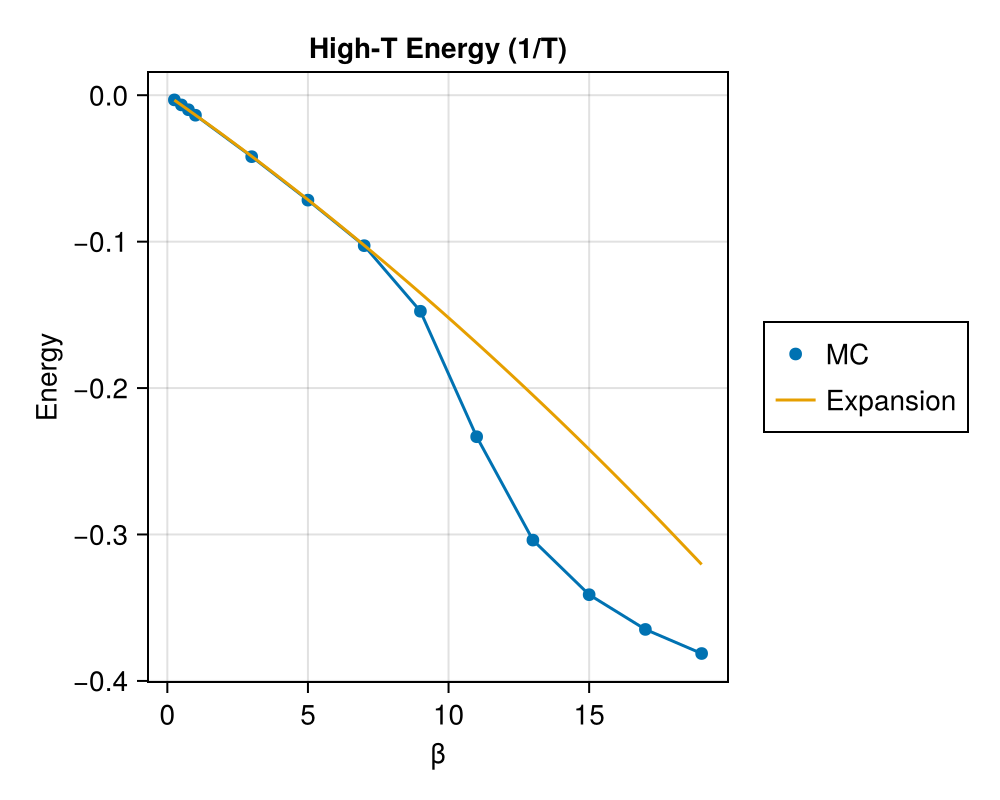

In [28]:
fig = Figure(size=(500,400))
fig[1,1] = ax2 = Axis(fig, title="High-T Energy (1/T)", xlabel="β", ylabel="Energy")
generate_plot!(ax2, :β, :Energy, results.data, label="MC")
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("fm", 2) ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,2], ax2)
fig

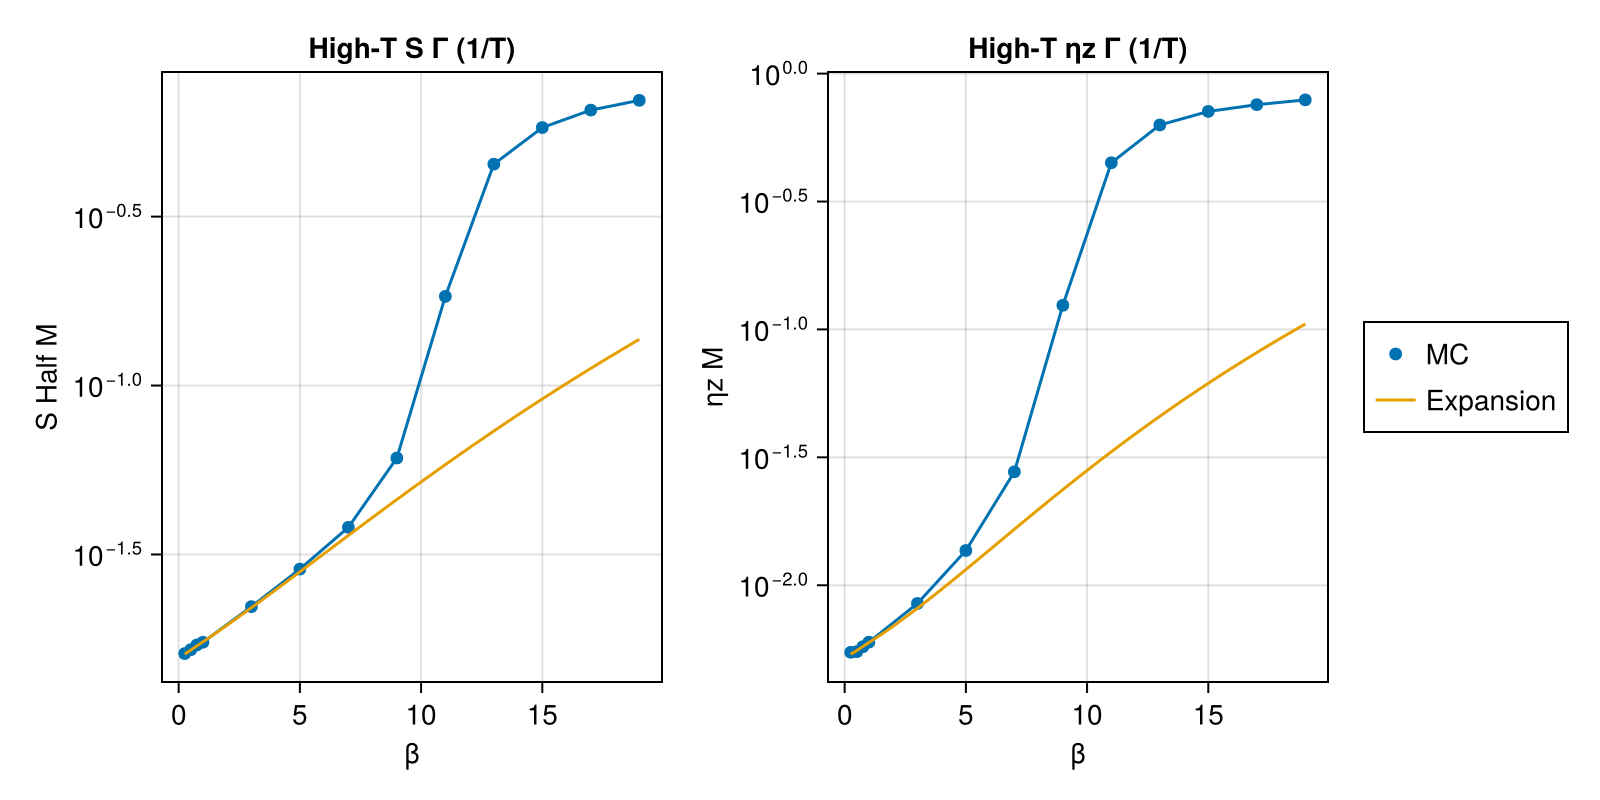

In [29]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S Γ (1/T)", xlabel="β", ylabel="S Half M", yscale=log10)
generate_plot!(ax1, :β, :sk_corr_Γ, results.data)
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("fm", 3, "s") ∘ (T -> 1/T))
fig[1,2] = ax2 = Axis(fig, title="High-T ηz Γ (1/T)", xlabel="β", ylabel="ηz M", yscale=log10)
generate_plot!(ax2, :β, :ηk_corr_Γ, results.data, label="MC") do ηk
    real(ηk[3,3])
end
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("fm", 3, "ηz") ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,3], ax2)
fig

## AFM-FE

In [39]:
results = JobResult("../jobs", "afm-fe-high-t")

JobResult("../jobs", "afm-fe-high-t", 16×90 DataFrame
 Row │ χs_half_M2       χηz_M3           χηx_half_M      χηy_M3           ηk_Γ ⋯
     │ Measureme…       Measureme…       Measureme…      Measureme…       Arra ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ 0.24445±0.00074  0.08354±0.00081  0.0835±0.00046  0.08356±0.00087  Comp ⋯
   2 │ 1.0786±0.0033    0.4072±0.0034    0.4186±0.0038   0.4075±0.0043    Comp
   3 │ 1.713±0.0058     0.7131±0.0078    0.7654±0.0045   0.7149±0.005     Comp
   4 │ 2.2017±0.0099    1.0195±0.0081    1.1234±0.0088   1.031±0.011      Comp
   5 │ 2.5615±0.0093    1.308±0.011      1.5101±0.0092   1.347±0.012      Comp ⋯
   6 │ 2.861±0.012      1.558±0.014      1.908±0.013     1.638±0.015      Comp
   7 │ 3.121±0.014      1.823±0.015      2.379±0.024     1.938±0.02       Comp
   8 │ 3.315±0.013      1.98±0.024       2.777±0.019     2.212±0.022      Comp
   9 │ 3.421±0.016      2.243±0.024      3.247±0.033     2.517±0.02

In [40]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.06557377049180328

In [41]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["afm_fe/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_fe/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_fe/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 0.0002 ± 0.0012
 2.7474 ± 0.0028
  0.504 ± 0.016
  0.094 ± 0.07

4-element Vector{Measurement{Float64}}:
 0.0156267 ± 8.9e-6
 -0.001976 ± 2.4e-5
  0.042896 ± 6.0e-5
  -0.00918 ± 0.00025

4-element Vector{Measurement{Float64}}:
 0.010426 ± 7.3e-6
 0.000134 ± 1.7e-5
 0.028639 ± 4.5e-5
  0.00589 ± 0.00019

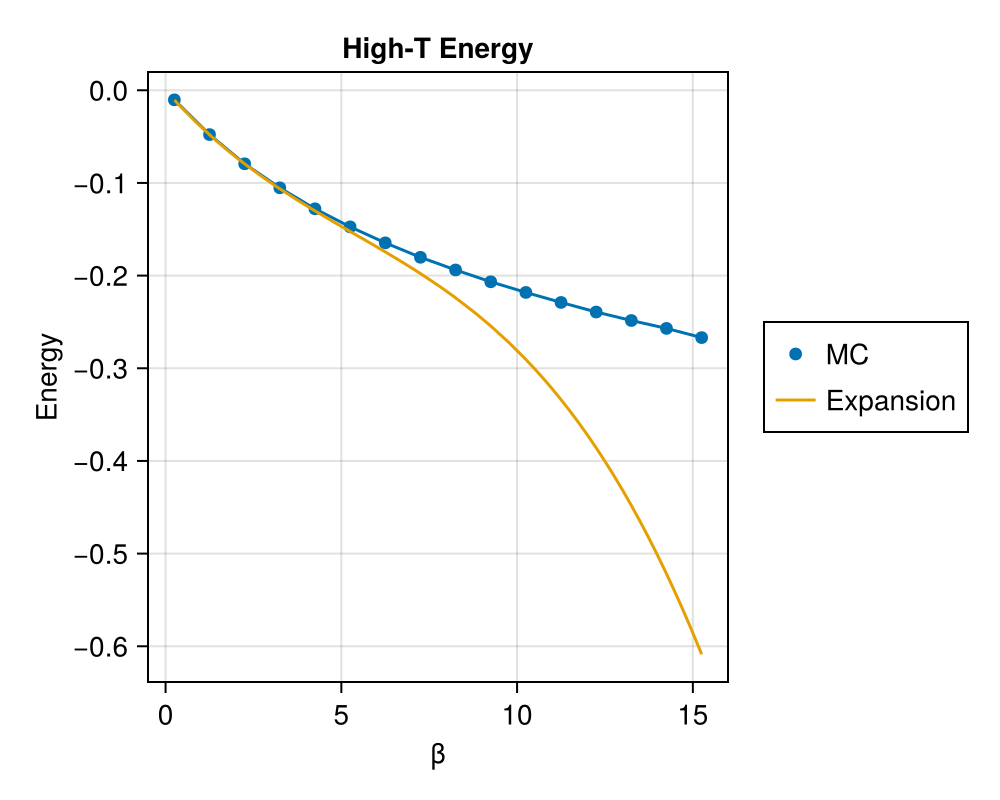

In [42]:
fig = Figure(size=(500,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="β", ylabel="Energy")
generate_plot!(ax1, :β, :Energy, results.data, label="MC")
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("afm_fe", 3) ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,2], ax1)
fig

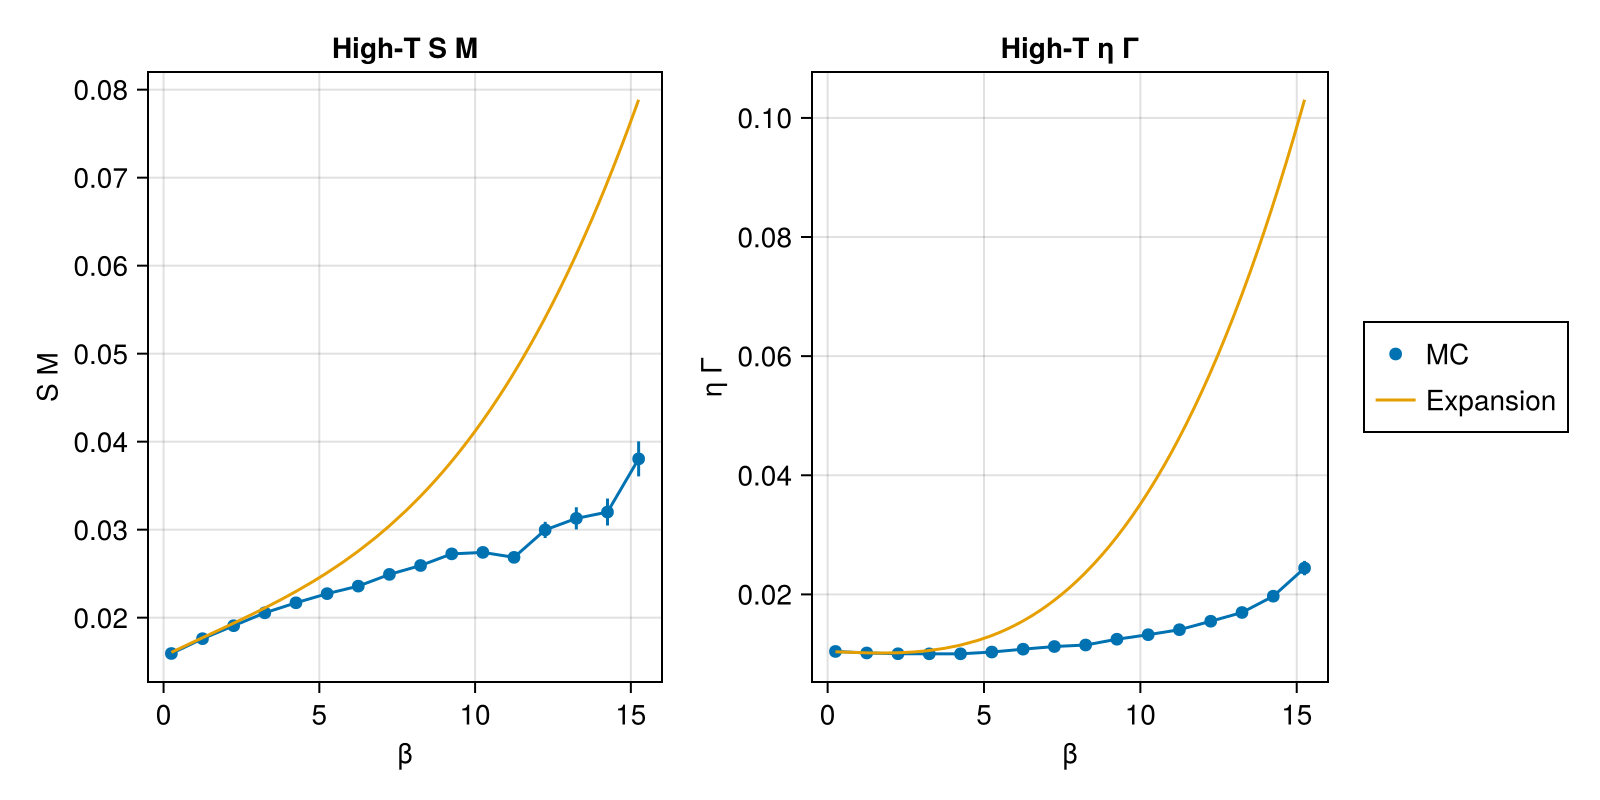

In [43]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S M", xlabel="β", ylabel="S M")
generate_plot!(ax1, :β, :sk_corr_M, results.data)
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("afm_fe", 3, "s") ∘ (T -> 1/T))
fig[1,2] = ax2 = Axis(fig, title="High-T η Γ", xlabel="β", ylabel="η Γ")
generate_plot!(ax2, :β, :ηk_corr_Γ, results.data, label="MC") do ηk
    real(getindex(ηk, 1, 1) + getindex(ηk, 2, 2))
end
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("afm_fe", 3, "η") ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,3], ax2)
fig

## AFM-AFE

In [44]:
results = JobResult("../jobs", "afm-afe-high-t")

JobResult("../jobs", "afm-afe-high-t", 14×90 DataFrame
 Row │ χs_half_M2       χηz_M3           χηx_half_M       χηy_M3            ηk ⋯
     │ Measureme…       Measureme…       Measureme…       Measureme…        Ar ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │  0.0996±0.00035  0.03318±0.00022  0.03313±0.00021   0.03313±0.00033  Co ⋯
   2 │  1.8846±0.006    0.6528±0.0049    0.7161±0.0036     0.6566±0.0038    Co
   3 │  3.326±0.012     1.162±0.01       1.4352±0.0079     1.2759±0.009     Co
   4 │  4.506±0.017     1.644±0.015      2.185±0.013       1.904±0.013      Co
   5 │  5.458±0.025     2.022±0.016      2.919±0.016       2.59±0.032       Co ⋯
   6 │  6.36±0.017      2.301±0.015      3.659±0.026       3.28±0.036       Co
   7 │  7.107±0.043     2.585±0.03       4.496±0.032       4.226±0.046      Co
   8 │  7.862±0.046     2.777±0.023      5.242±0.048       5.44±0.12        Co
   9 │  8.419±0.043     3.055±0.03       5.823±0.059       6.88±0.

In [45]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.038314176245210725

In [46]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["afm_afe/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_afe/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_afe/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 0.00098 ± 0.00065
   2.209 ± 0.0014
  0.2303 ± 0.0071
  0.0039 ± 0.028

4-element Vector{Measurement{Float64}}:
  0.0069441 ± 1.7e-6
 -0.0003925 ± 5.2e-6
   0.015318 ± 1.2e-5
  -0.001101 ± 4.4e-5

4-element Vector{Measurement{Float64}}:
 0.0046267 ± 2.0e-6
  -3.45e-5 ± 4.3e-6
  0.010256 ± 1.0e-5
  0.000783 ± 3.7e-5

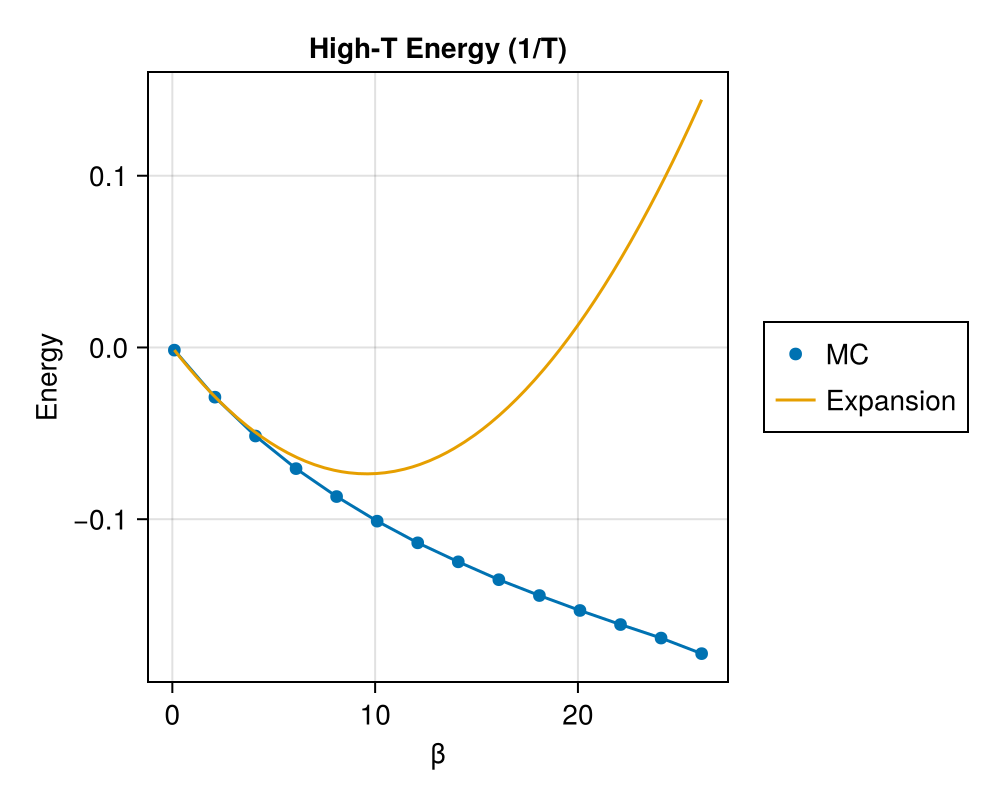

In [51]:
fig = Figure(size=(500,400))
fig[1,1] = ax2 = Axis(fig, title="High-T Energy (1/T)", xlabel="β", ylabel="Energy")
generate_plot!(ax2, :β, :Energy, results.data, label="MC")
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("afm_afe", 2, L=12) ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,2], ax2)
save("plots/afm-afe-highT-energy.png", fig)
fig

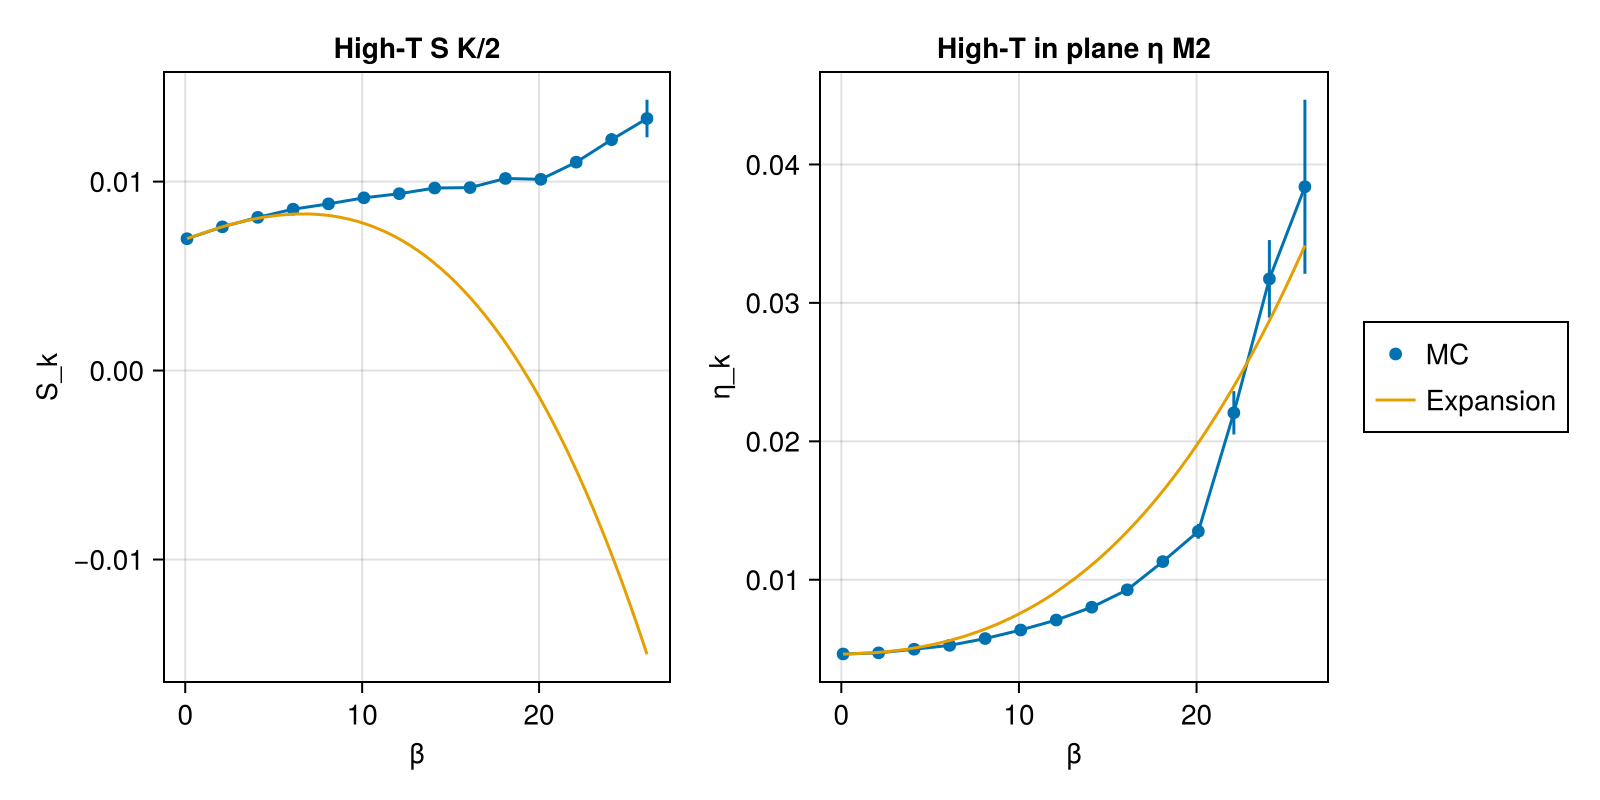

In [53]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S K/2", xlabel="β", ylabel="S_k")
generate_plot!(ax1, :β, :sk_corr_half_K, results.data)
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("afm_afe", 3, "s") ∘ (T -> 1/T))
fig[1,2] = ax2 = Axis(fig, title="High-T in plane η M2", xlabel="β", ylabel="η_k")
generate_plot!(ax2, :β, :ηk_corr_M2, results.data, label="MC") do ηk
    real(getindex(ηk, 1, 1) + getindex(ηk, 2, 2))
end
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("afm_afe", 3, "η") ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,3], ax2)
save("plots/afm-afe-highT-spins.png", fig)
fig